<a href="https://colab.research.google.com/github/anushka-tripathy/Reliance-Stock-Analysis-Prediction/blob/main/Reliance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=cf07f5c890a55fdfab87cbfb2dbd9d88c334209ea79a13b20a6b2aae7c74599d
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
# =======================
# Step 1: Import Libraries
# =======================
import yfinance as yf       # To get stock market data
import pandas as pd         # To handle tables of data
import numpy as np          # For calculations
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")  # Nice plot style

from ta.momentum import RSIIndicator  # RSI indicator
from ta.trend import MACD             # MACD indicator

from sklearn.model_selection import train_test_split  # To split data
from sklearn.ensemble import RandomForestClassifier  # Machine Learning model
from sklearn.metrics import accuracy_score, confusion_matrix  # Performance metrics


In [ ]:
# =======================
# Step 2: Fetch Stock Data
# =======================

ticker = "RELIANCE.NS"

data = yf.download(
    ticker,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)

# 🔹 Fix yfinance MultiIndex columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# 🔹 Ensure Close is a true 1-D Series
data['Close'] = data['Close'].squeeze()

# 🔹 Drop missing values
data.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [ ]:
# =======================
# Step 3: Feature Engineering
# =======================
data['Return'] = data['Close'].pct_change()          # Daily % change
data['MA10'] = data['Close'].rolling(10).mean()     # 10-day moving average
data['MA50'] = data['Close'].rolling(50).mean()     # 50-day moving average

# ✅ Fix for RSI and MACD — always pass 1D pandas Series
data['RSI'] = RSIIndicator(close=data['Close']).rsi()     # RSI indicator

macd = MACD(close=data['Close'])
data['MACD'] = macd.macd()                          # MACD line
data['Signal'] = macd.macd_signal()                 # MACD signal line

data.dropna(inplace=True)  # Remove rows with missing data

In [ ]:
# =======================
# Step 4: Target Variable
# =======================
# 1 = Price goes up tomorrow, 0 = Price goes down or stays same
data['Target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, 0)

# 🔹 Remove last row (no future price available)
data = data.iloc[:-1]




In [ ]:
# =======================
# Step 5: Features & Train/Test Split
# =======================
features = ['Return', 'MA10', 'MA50', 'RSI', 'MACD', 'Signal']
X = data[features]
y = data['Target']

# Split data (80% train, 20% test) without shuffling (time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
# =======================
# Step 6: Train Random Forest Model
# =======================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
# =======================
# Step 7: Evaluate Model
# =======================
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {acc*100:.2f}%")
print("Confusion Matrix:\n", cm)

Model Accuracy: 54.40%
Confusion Matrix:
 [[119  72]
 [104  91]]


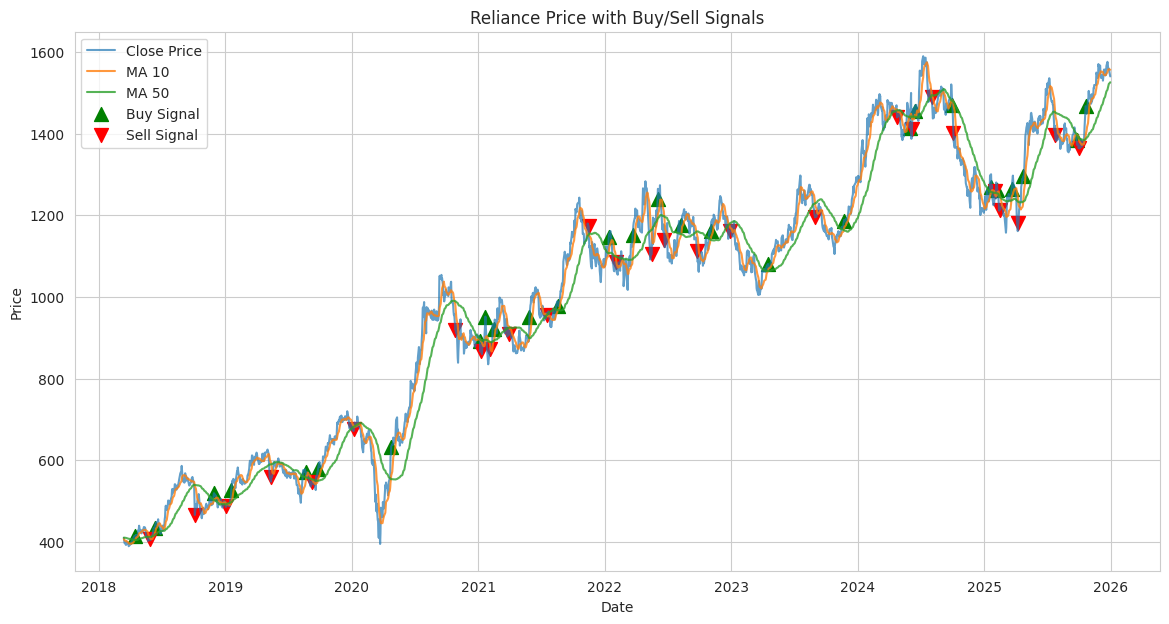

In [ ]:
# =======================
# Step 8: Visualization
# =======================

# 8a: Generate Buy/Sell signals
data['Buy_Signal'] = np.where(
    (data['MA10'] > data['MA50']) & (data['MA10'].shift(1) <= data['MA50'].shift(1)),
    data['Close'], np.nan
)
data['Sell_Signal'] = np.where(
    (data['MA10'] < data['MA50']) & (data['MA10'].shift(1) >= data['MA50'].shift(1)),
    data['Close'], np.nan
)

plt.figure(figsize=(14, 7))

# Plot Close Price and Moving Averages
plt.plot(data.index, data['Close'], label='Close Price', alpha=0.7)
plt.plot(data.index, data['MA10'], label='MA 10', alpha=0.8)
plt.plot(data.index, data['MA50'], label='MA 50', alpha=0.8)

# Plot Buy Signals
plt.scatter(
    data.index,
    data['Buy_Signal'],
    label='Buy Signal',
    marker='^',
    color='green',
    s=100
)

# Plot Sell Signals
plt.scatter(
    data.index,
    data['Sell_Signal'],
    label='Sell Signal',
    marker='v',
    color='red',
    s=100
)

plt.title('Reliance Price with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


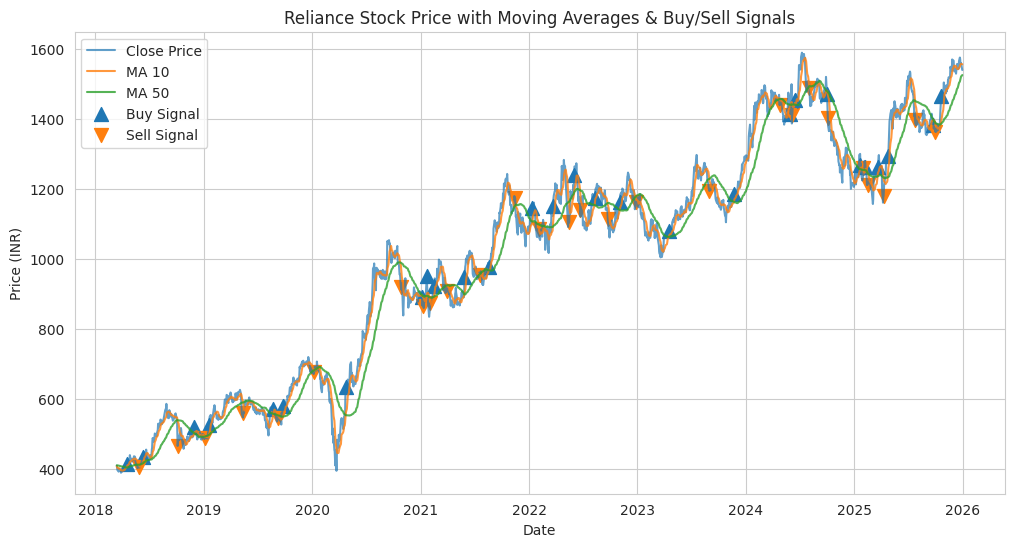

In [ ]:

# 8b: Plot Closing Price, MAs, and Signals
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price', alpha=0.7)
plt.plot(data['MA10'], label='MA 10', alpha=0.8)
plt.plot(data['MA50'], label='MA 50', alpha=0.8)
plt.scatter(data.index, data['Buy_Signal'], marker='^', label='Buy Signal', s=100)
plt.scatter(data.index, data['Sell_Signal'], marker='v', label='Sell Signal', s=100)
plt.title('Reliance Stock Price with Moving Averages & Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()




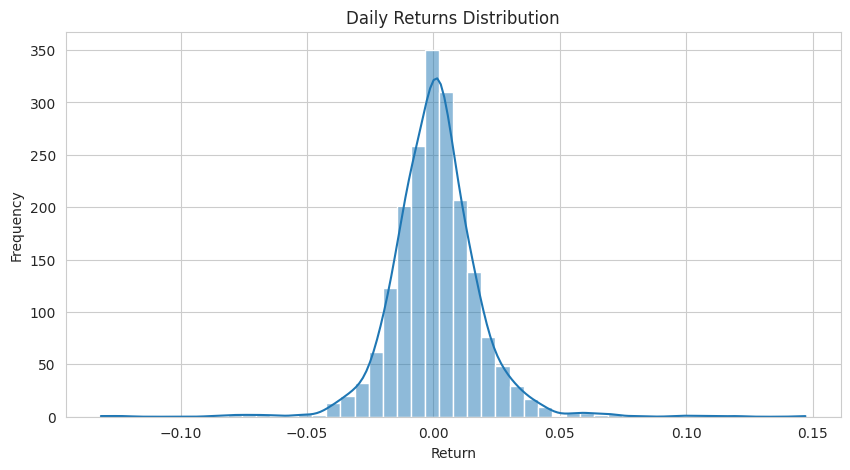

In [ ]:
# 8c: Daily Returns Distribution
plt.figure(figsize=(10,5))
sns.histplot(data['Return'], bins=50, kde=True)
plt.title('Daily Returns Distribution')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()


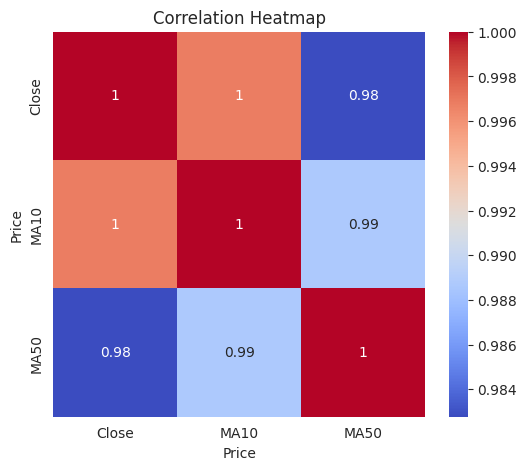

In [ ]:
# 8d: Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(data[['Close','MA10','MA50']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


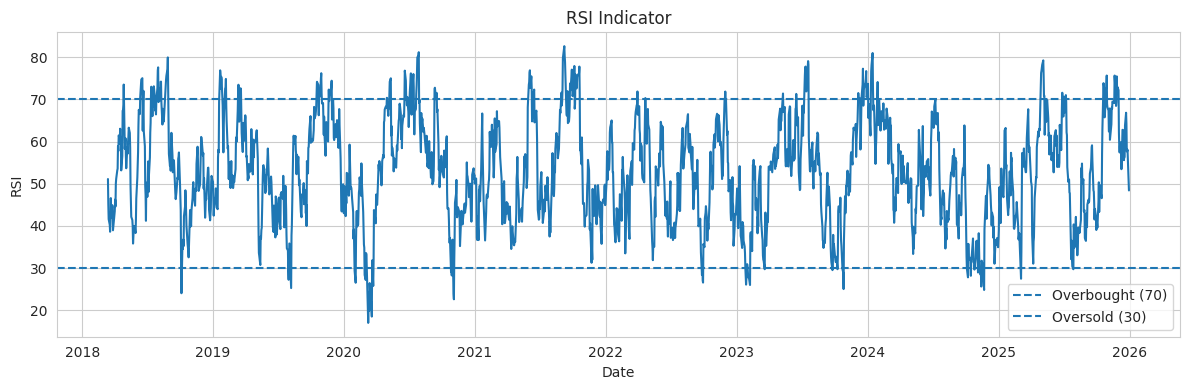

In [ ]:
# 8e: Plot RSI
plt.figure(figsize=(12,4))
plt.plot(data['RSI'])
plt.axhline(70, linestyle='--', label='Overbought (70)')
plt.axhline(30, linestyle='--', label='Oversold (30)')
plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.tight_layout()
plt.show()

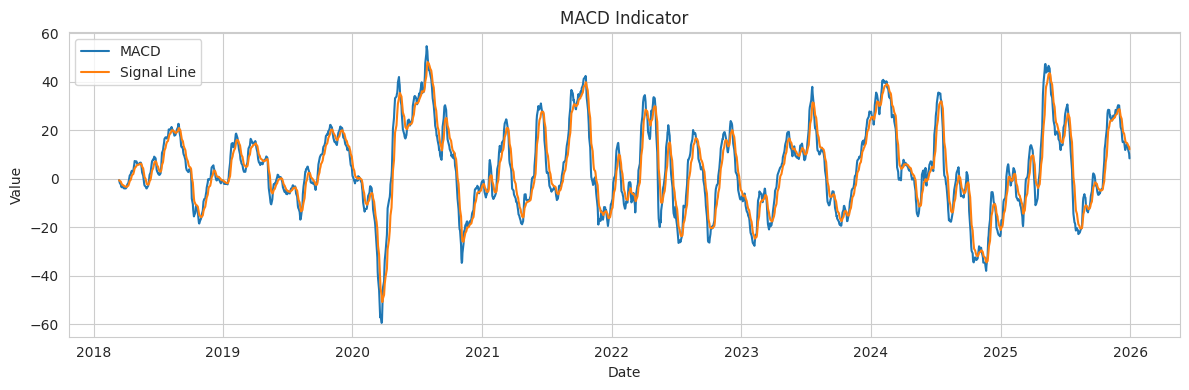

In [ ]:
# 8f: Plot MACD
plt.figure(figsize=(12,4))
plt.plot(data['MACD'], label='MACD')
plt.plot(data['Signal'], label='Signal Line')
plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()